# Telco Customer Churn - Exploratory Data Analysis

This notebook explores the cleaned Telco Customer Churn dataset to understand customer characteristics, churn distribution, and relationships that may be useful for machine-learning model development.

In [166]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [167]:
DATA_PATH = Path("../data/processed/telco_customer_churn_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [168]:
df.shape

(7043, 21)

In [169]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [170]:
df.isna().sum().sort_values(ascending = False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [171]:
df.duplicated().sum()

np.int64(0)

In [172]:
df["customerID"].duplicated().sum()

np.int64(0)

In [173]:
df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
    ]
].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [174]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [175]:
df["Churn"].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [176]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize = True)
    .mul(100)
    .round(2)
)

churn_rate

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

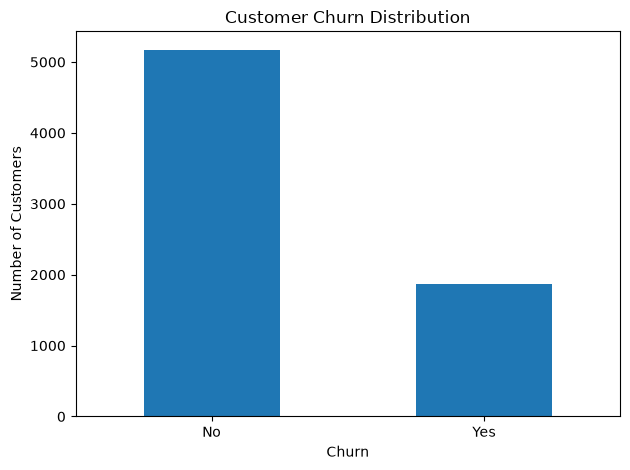

In [177]:
df["Churn"].value_counts().plot(
    kind = "bar",
    title = "Customer Churn Distribution",
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [178]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize = "index",
).mul(100)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


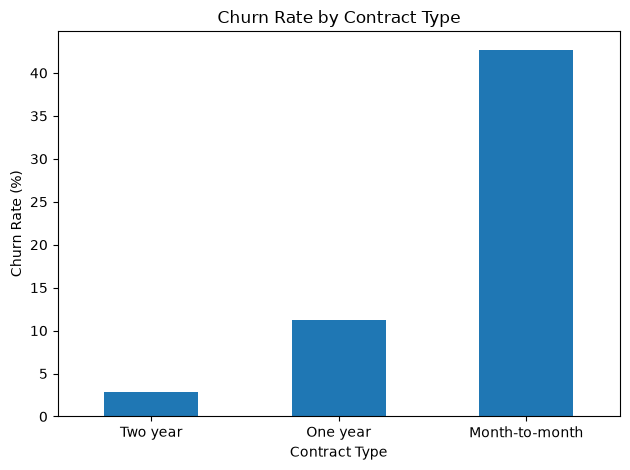

In [179]:
contract_churn["Yes"].sort_values().plot(
    kind = "bar",
    title = "Churn Rate by Contract Type",
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [180]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


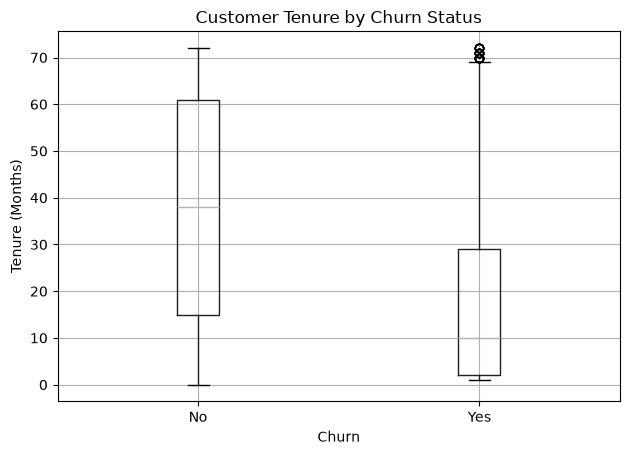

In [181]:
df.boxplot(
    column = "tenure",
    by = "Churn",
)

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

In [182]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


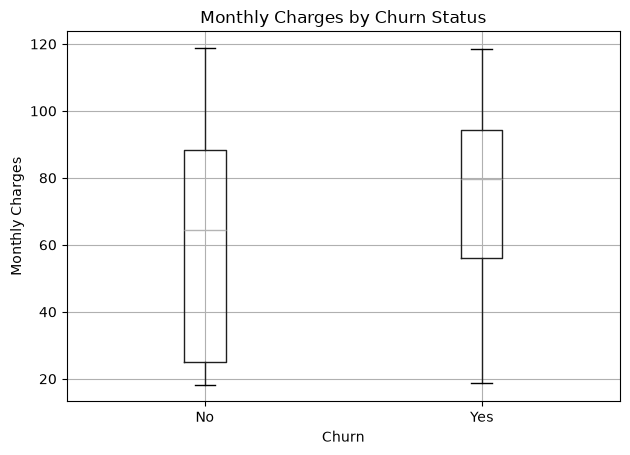

In [183]:
df.boxplot(
    column = "MonthlyCharges",
    by = "Churn",
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [184]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize = "index",
).mul(100)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


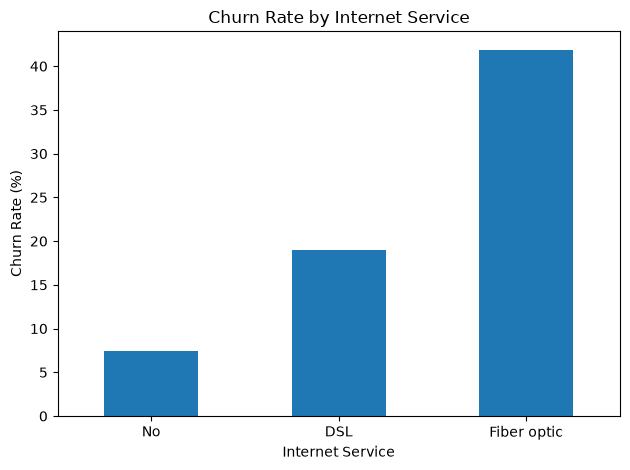

In [185]:
internet_churn["Yes"].sort_values().plot(
    kind = "bar",
    title = "Churn Rate by Internet Service",
)

plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [186]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize = "index"
).mul(100)

payment_churn.sort_values(
    "Yes",
    ascending = False,
)

Churn,No,Yes
PaymentMethod,,
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101


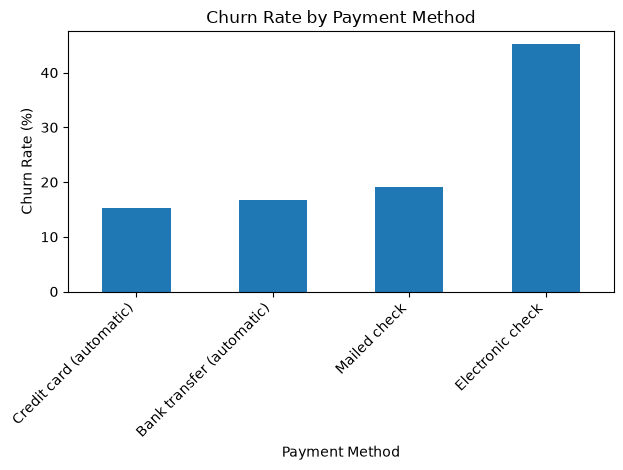

In [187]:
payment_churn["Yes"].sort_values().plot(
    kind = "bar",
    title = "Churn Rate by Payment Method",
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation =45, ha = "right")
plt.tight_layout()
plt.show()

In [188]:
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

df[numeric_columns].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


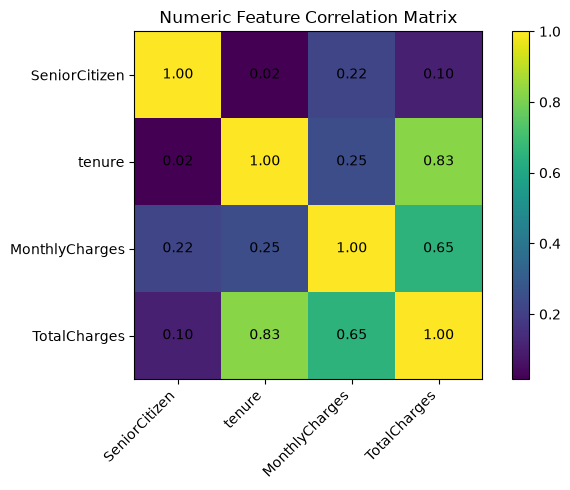

In [189]:
correlation_matrix = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize = (7, 5))

image = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))

ax.set_xticklabels(
    numeric_columns,
    rotation = 45,
    ha = "right",
)

ax.set_yticklabels(numeric_columns)

for row in range(len(numeric_columns)):
    for column in range(len(numeric_columns)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha = "center",
            va = "center",
        )


plt.title("Numeric Feature Correlation Matrix")
plt.colorbar(image)
plt.tight_layout()
plt.show()

## Preliminary Findings

- The dataset contains 7,043 customer records with no duplicate customer IDs and no remaining missing values after cleaning.

- Approximately 26.54% of customers churned, while 73.46% remained. This indicates a moderate class imbalance that should be considered during model evaluation.

- Contract type shows a strong relationship with churn. Month-to-month customers had the highest churn rate at approximately 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts.

- Customer tenure differs substantially between churn groups. Customers who churned had an average tenure of approximately 17.98 months and a median tenure of 10 months, while customers who remained had an average tenure of approximately 37.57 months and a median tenure of 38 months. This suggests that newer customers may be more likely to churn.

- Customers who churned also had higher monthly charges. Their average monthly charge was approximately $74.44 compared with $61.27 for customers who remained. The median monthly charge was approximately $79.65 for churned customers versus $64.43 for non-churned customers.

- Internet service type shows notable differences in churn. Fiber optic customers had the highest churn rate at approximately 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

- Payment method also shows substantial differences. Customers using electronic checks had the highest churn rate at approximately 45.29%. Churn rates were lower for mailed checks at 19.11%, automatic bank transfers at 16.71%, and automatic credit card payments at 15.24%.

- Among the numeric variables, tenure and TotalCharges have a strong positive correlation of approximately 0.83. MonthlyCharges and TotalCharges also have a moderately strong positive correlation of approximately 0.65. These relationships should be considered during feature preparation and model interpretation.

- Customer ID is useful for record validation, duplicate detection, and traceability, but it should not be included as a predictive feature because it is an identifier rather than a meaningful customer characteristic.

These findings are exploratory associations and do not establish causation. They will guide feature engineering, preprocessing, model selection, and evaluation in later stages of the project.